# Project Name: Children Mental health Prediction 
Dataset: MICS 2019 cluster servay

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
pd.pandas.set_option('display.max_columns',None)

In [4]:
df= pd.read_csv("ch_subset1.csv")
#df=df_load[['UB2', 'UCD2A', 'UCD2B','UCD2C', 'UCD2D', 'UCD2E', 'UCD2F', 'UCD2G', 'UCD2H', 'UCD2I', 'UCD2J','UCD2K','UCF17','BD2', 'AN8', 'HH6', 'HH7', 'HL4', 'windex5', 'melevel']]
df.columns

Index(['UCD2A', 'UCD2C', 'UCD2D', 'UCD2G', 'UCD2H', 'UCD2I', 'UCD2J', 'UCD2K',
       'UCF17', 'AN4', 'AN8', 'AN11', 'HH6', 'HL4', 'HAP', 'WAP', 'WHP', 'BMI',
       'windex5', 'melevel'],
      dtype='object')

In [5]:
#df=dataLoad.drop(['Unnamed: 0'], axis=1)

In [6]:
"""
df.columns=['Age of woman','Currently married','Age of husband','Husband has more wives','Children dead','Children ever born',
           'Received prenatal care','Times received prenatal care','Blood pressure','Urine sample','Blood sample',
           'Has own immunization card','Tetanus toxoid injection taken','New born birth weight','Using method to avoid pregnancy',
           'Estimation of happiness','Area','Sex of newborn','Wealth index','Education level']
           """

"\ndf.columns=['Age of woman','Currently married','Age of husband','Husband has more wives','Children dead','Children ever born',\n           'Received prenatal care','Times received prenatal care','Blood pressure','Urine sample','Blood sample',\n           'Has own immunization card','Tetanus toxoid injection taken','New born birth weight','Using method to avoid pregnancy',\n           'Estimation of happiness','Area','Sex of newborn','Wealth index','Education level']\n           "

In [7]:
df.head(5)

,UCD2A,UCD2C,UCD2D,UCD2G,UCD2H,UCD2I,UCD2J,UCD2K,UCF17,AN4,AN8,AN11,HH6,HL4,HAP,WAP,WHP,BMI,windex5,melevel
0,NO,NO,YES,NO,YES,NO,NO,NO,NO DIFFICULTY,4.0,16.3,106.4,URBAN,MALE,27.5,15.4,20.6,14.40,Richest,Higher secondary+
1,NO,YES,YES,NO,NO,NO,NO,NO,NaN,1.0,7.8,76.2,URBAN,MALE,0.6,0.1,0.2,13.43,Middle,Higher secondary+
2,NO,NO,NO,NO,NO,NO,NO,NO,NO DIFFICULTY,3.0,9.8,84.6,URBAN,FEMALE,0.4,0.1,3.4,13.69,Fourth,Primary
3,NO,YES,YES,NO,NO,NO,NO,NO,NO DIFFICULTY,3.0,14.7,99.1,URBAN,MALE,27.7,19.0,27.5,14.97,Richest,Higher secondary+
4,YES,NO,NO,NO,NO,NO,NO,NO,NO DIFFICULTY,4.0,13.0,96.1,URBAN,FEMALE,1.3,1.6,13.9,14.08,Richest,Higher secondary+


In [8]:
df.shape

(24686, 20)

# Missing Values

In [9]:
df.isnull().sum().sum()

70893

In [10]:
# percent of data that is missing per column
percent_missing = (df.isnull().sum() * 100 / len(df)).sort_values(ascending=False)
percent_missing[0:10]

UCF17    43.052742
UCD2A    24.754922
UCD2D    24.754922
UCD2G    24.754922
UCD2H    24.754922
UCD2I    24.754922
UCD2J    24.754922
UCD2K    24.754922
UCD2C    24.754922
AN11      7.522482
dtype: float64

In [11]:
percent_missing= (df['UCF17'].isnull().sum() * 100 / len(df['UCF17']))
percent_missing

43.05274244511059

In [12]:
# Below code gives percentage of null in every column
null_percentage = df.isnull().sum()/df.shape[0]*100

# Below code gives list of columns having more than 60% null
col_to_drop = null_percentage[null_percentage>50].keys()

In [13]:
col_to_drop

Index([], dtype='object')

In [14]:
#df1 = df.drop(col_to_drop, axis=1)
df1 = df.loc[df['UCF17'].notnull()] 
df1.shape

(14058, 20)

# Uniqe values in each features

In [15]:
count=0
for col in df1.columns:
    print(col)
    print(df1[col].unique())

UCD2A
['NO' 'YES' 'NO RESPONSE']
UCD2C
['NO' 'YES' 'NO RESPONSE']
UCD2D
['YES' 'NO' 'NO RESPONSE']
UCD2G
['NO' 'YES' 'NO RESPONSE']
UCD2H
['YES' 'NO']
UCD2I
['NO' 'YES' 'NO RESPONSE']
UCD2J
['NO' 'YES']
UCD2K
['NO' 'YES' 'NO RESPONSE']
UCF17
['NO DIFFICULTY' 'SOME DIFFICULTY' 'A LOT OF DIFFICULTY'
 'CANNOT LEARN THINGS AT ALL' 'NO RESPONSE']
AN4
[4. 3. 2.]
AN8
[16.3  9.8 14.7 13.  11.7 12.3 15.1 15.9 14.8 11.6 15.7 14.2 15.3 10.3
 10.  11.9 11.2 11.4 13.1 13.2 13.8  9.6 16.5 10.6 10.8 15.2  9.9 12.1
 12.9 13.6 13.4 11.  16.2  9.3 10.4 11.3 14.4 11.8 14.  18.4  8.9  9.2
 12.4 12.6 11.5 14.3 12.  15.8 12.5 12.7 13.7 11.1 16.6 10.7 10.9  8.2
 99.6 17.6 14.6 16.8  9.1 10.5  9.4  9.7 13.3 15.6 15.  12.2 14.1 20.3
 12.8 17.3 16.  14.9  7.  19.8 23.5 99.3 18.5  7.4 17.2 16.1 16.4 17.1
 15.4 13.5  8.6 22.6 13.9 17.7  8.  10.1 10.2  8.8  8.3 16.7 19.  16.9
  6.4  6.2  6.9  8.1 18.3 14.5  7.9 18.1 17.4  8.7  9.5 99.4  7.6 18.
 18.2 17.5 31.7 15.5  8.4 19.4 17.  19.7 18.8 19.2  9.  17.8 19.1 20.1

In [16]:
#df1 = df.drop("MN34", axis=1)

In [17]:
for col in df1.columns:
    if len(df1[col].unique()) == 1:
        print(col)
        df1.drop(col,inplace=True,axis=1)
df1.shape

(14058, 20)

# Datatype of each features

In [18]:
from pandas.api.types import infer_dtype

for column in df1.columns:
    print(column,':',infer_dtype(df1[column]))

UCD2A : string
UCD2C : string
UCD2D : string
UCD2G : string
UCD2H : string
UCD2I : string
UCD2J : string
UCD2K : string
UCF17 : string
AN4 : floating
AN8 : floating
AN11 : floating
HH6 : string
HL4 : string
HAP : floating
WAP : floating
WHP : floating
BMI : floating
windex5 : string
melevel : string


In [19]:
for column in df1.columns:
    if(infer_dtype(df1[column])=="mixed"):
        df1[column]=pd.to_numeric(df1[column],errors='coerce')
        df1[column] = df1[column].apply(lambda elt: str(int(elt)) if isinstance(elt, float) else str(elt))

In [20]:
#df1['Times received prenatal care'] = df1['Times received prenatal care'].astype(int)

# Description

In [21]:
import numpy as np

numeric_features = df1.select_dtypes(include=[np.number])
numeric_features.describe()

,AN4,AN8,AN11,HAP,WAP,WHP,BMI
count,14058.000000,14058.000000,13820.000000,14057.000000,14057.000000,14057.000000,14057.000000
mean,3.003343,15.729400,118.117475,25.686711,17.671253,27.695554,18.587474
std,0.811318,15.562619,148.023706,30.054771,25.377152,27.953349,17.657620
min,2.000000,1.100000,39.600000,0.000000,0.000000,0.000000,1.100000
25%,2.000000,11.300000,87.500000,2.800000,1.600000,6.600000,13.830000
50%,3.000000,12.800000,93.600000,12.700000,6.400000,17.100000,14.660000
75%,4.000000,14.500000,99.700000,39.000000,21.800000,40.100000,15.690000
max,4.000000,99.900000,999.900000,99.900000,99.900000,99.900000,99.990000


In [22]:
categorical_features = df1.select_dtypes(exclude=[np.number])
categorical_features.describe()

,UCD2A,UCD2C,UCD2D,UCD2G,UCD2H,UCD2I,UCD2J,UCD2K,UCF17,HH6,HL4,windex5,melevel
count,14058,14058,14058,14058,14058,14058,14058,14058,14058,14058,14058,14058,14058
unique,3,3,3,3,2,3,2,3,5,2,2,6,4
top,NO,NO,YES,NO,NO,NO,NO,NO,NO DIFFICULTY,RURAL,MALE,Poorest,Secondary
freq,7272,7948,12147,11854,10708,9312,7418,13391,13179,11473,7299,3579,6831


# Exploratory Data Analysis

## Univariate Analysis

In [23]:
features_with_na=[features for features in df1.columns if df1[features].isnull().sum()>1]


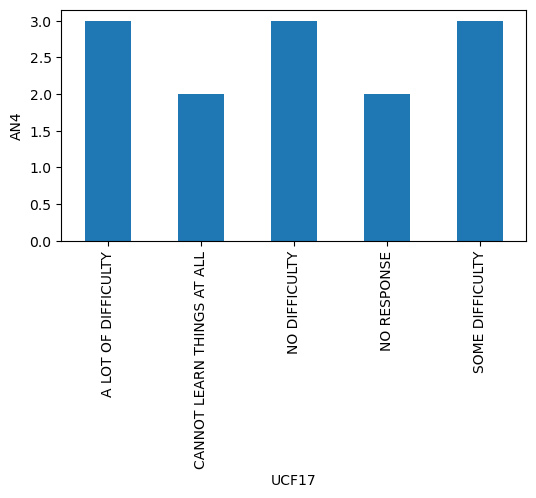

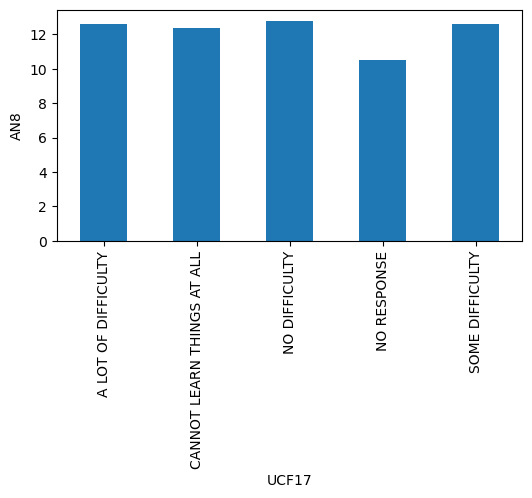

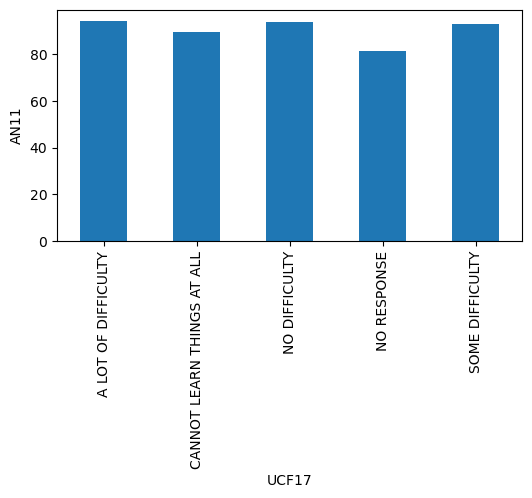

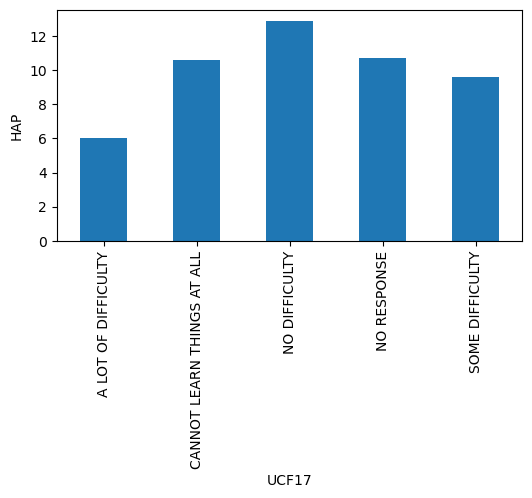

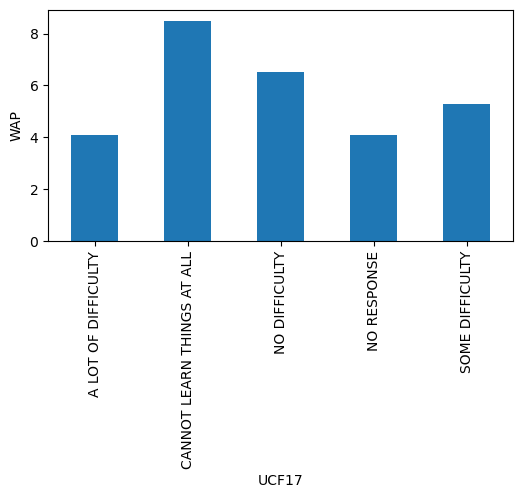

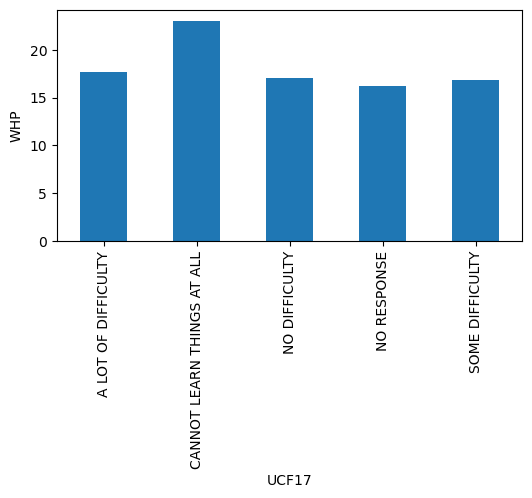

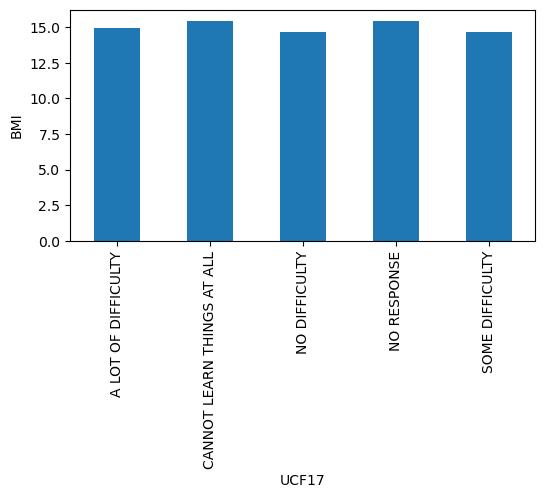

In [24]:
for feature in numeric_features.columns:
    #calculate sum of values by group
    df_groups = df1.groupby('UCF17')[feature].median()
    #create bar plot by group
    df_groups.plot(kind='bar', title='',
               ylabel=feature, xlabel='UCF17', figsize=(6, 3))
    plt.show()
    

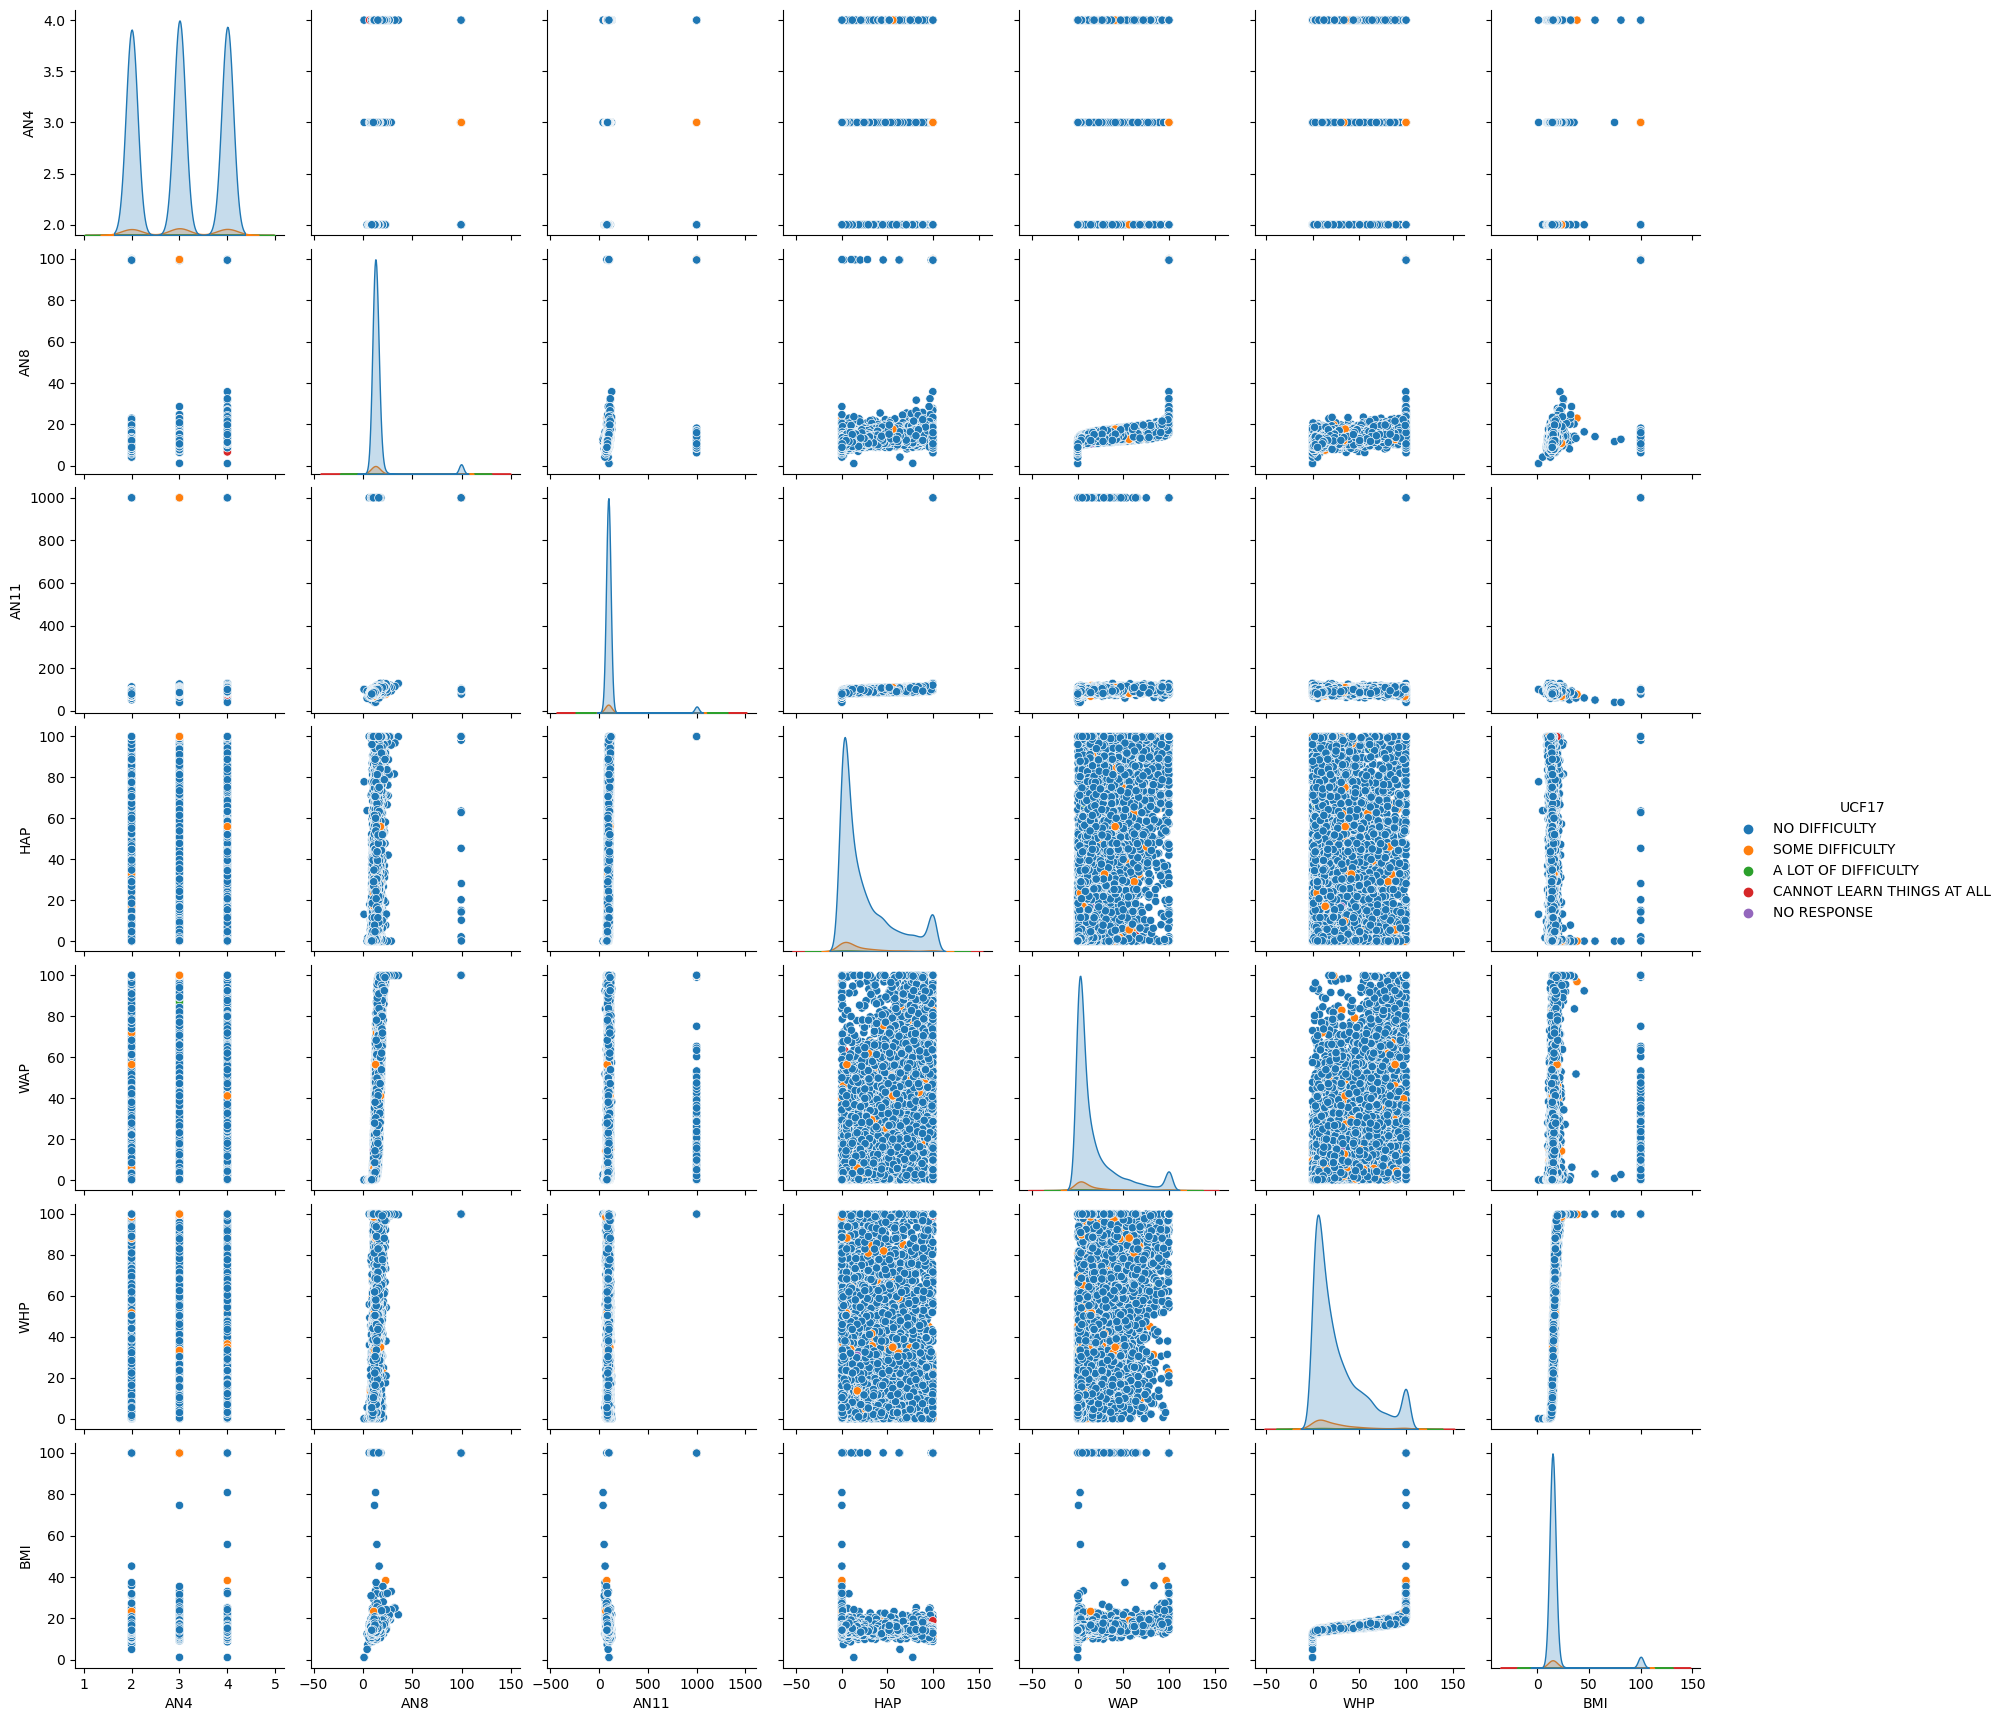

In [25]:

sns.pairplot(df1, hue='UCF17')

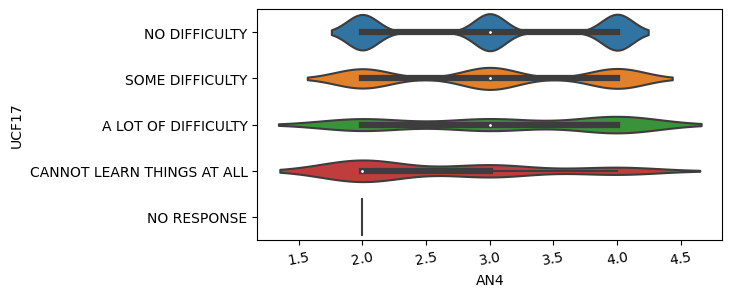

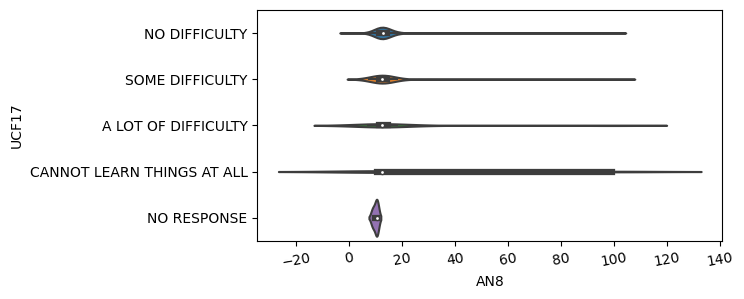

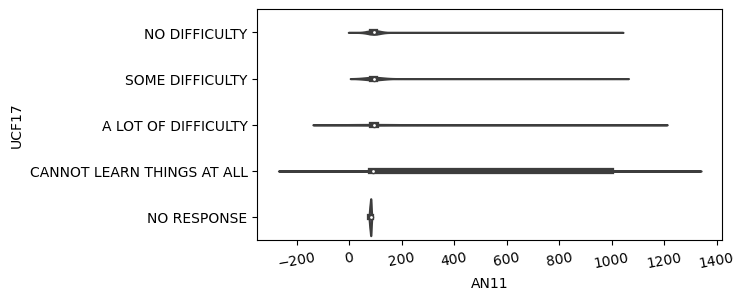

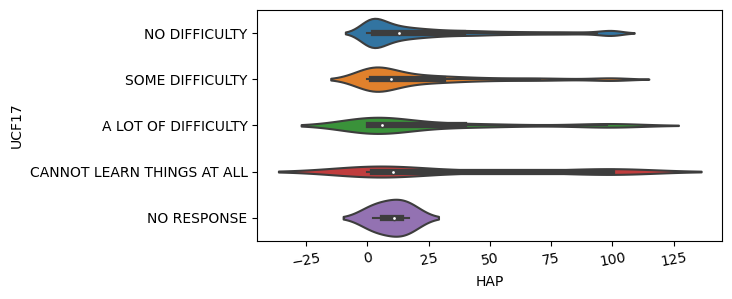

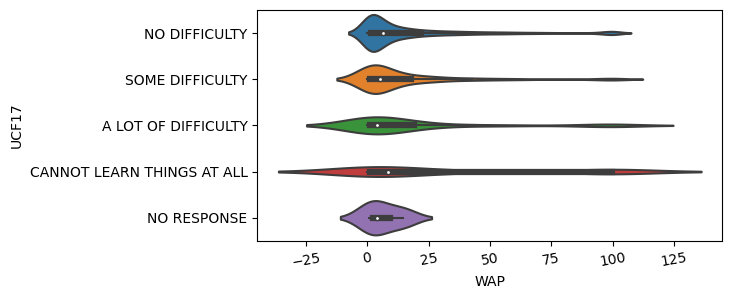

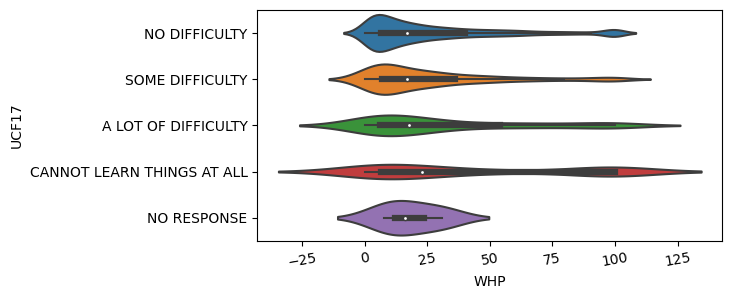

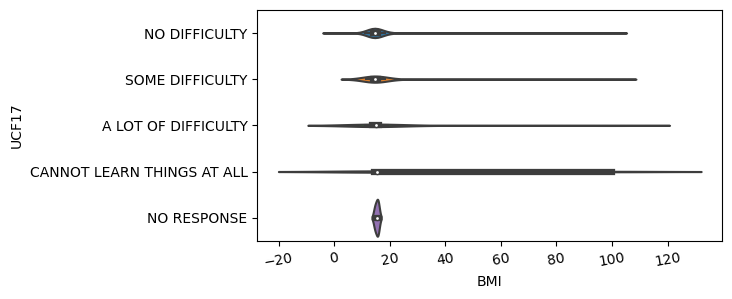

In [26]:
for column in numeric_features.columns:
    plt.figure(figsize=(6,3))
    sns.violinplot(data=df, x=column, y="UCF17")
    plt.xticks(rotation = 10)
    plt.show()

In [27]:
"""
for column in numeric_features.columns:
    plt.figure(figsize=(6,3))
    sns.scatterplot(x=column, y='LS1', data=df1)
    plt.xticks(rotation = 10)
    plt.show()
"""

"\nfor column in numeric_features.columns:\n    plt.figure(figsize=(6,3))\n    sns.scatterplot(x=column, y='LS1', data=df1)\n    plt.xticks(rotation = 10)\n    plt.show()\n"

### Categorical Data

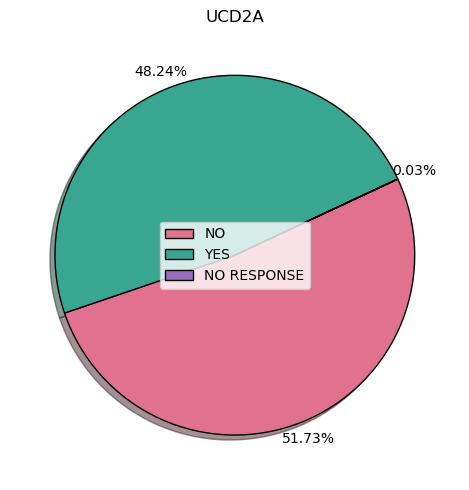

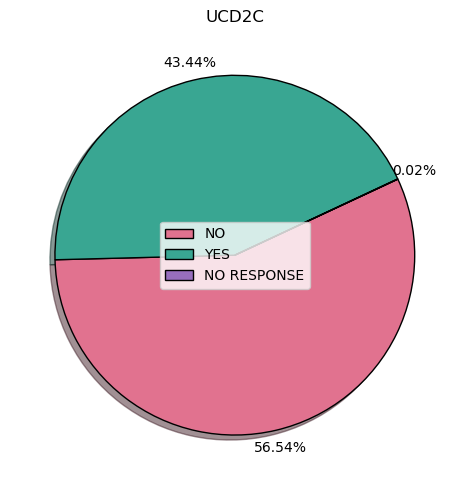

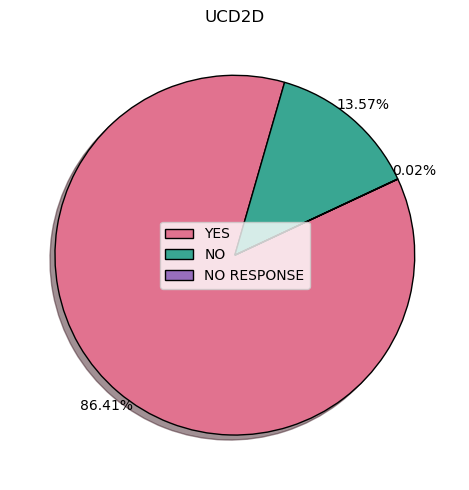

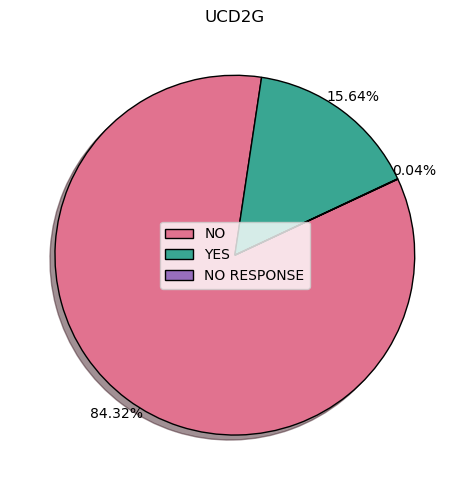

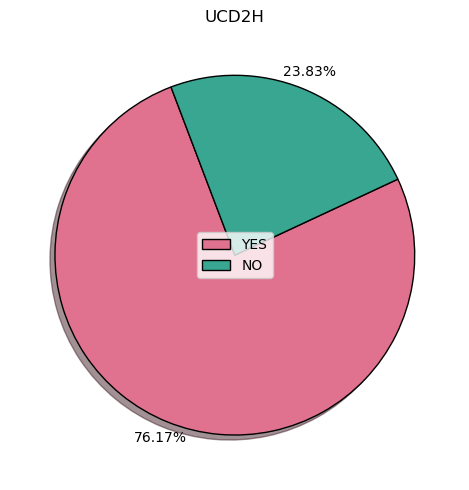

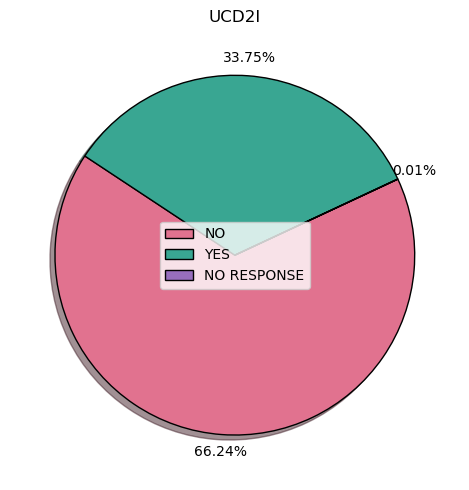

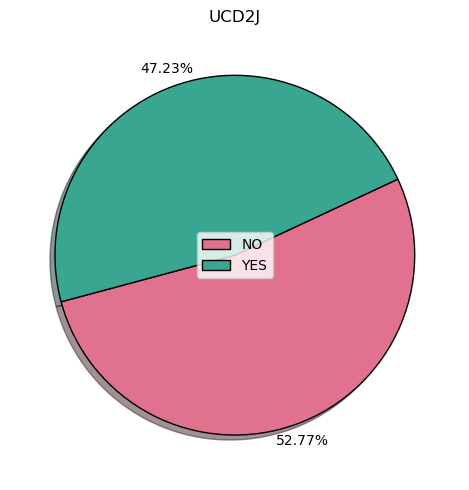

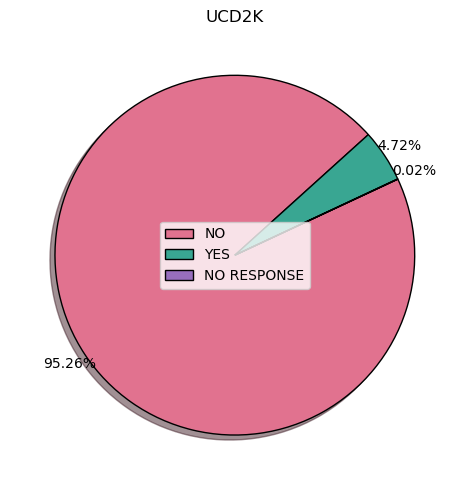

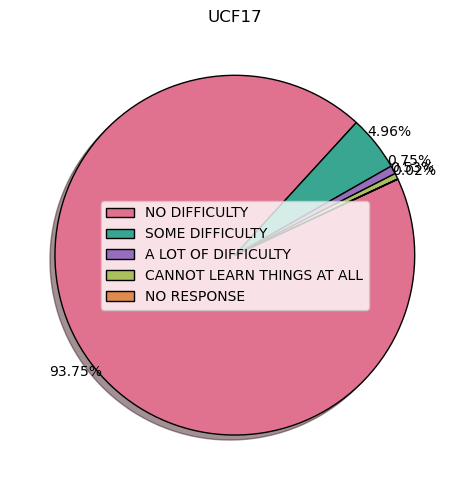

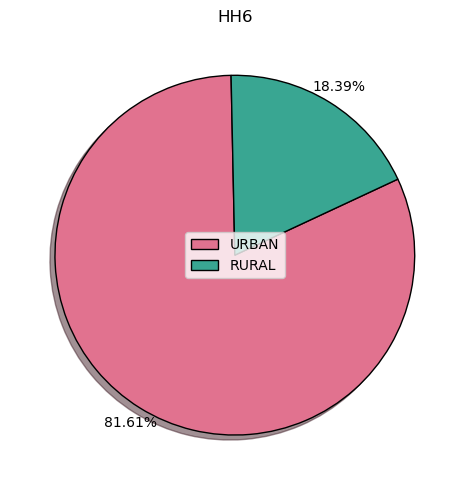

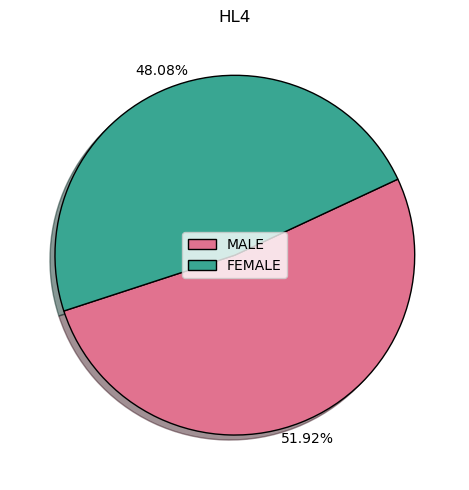

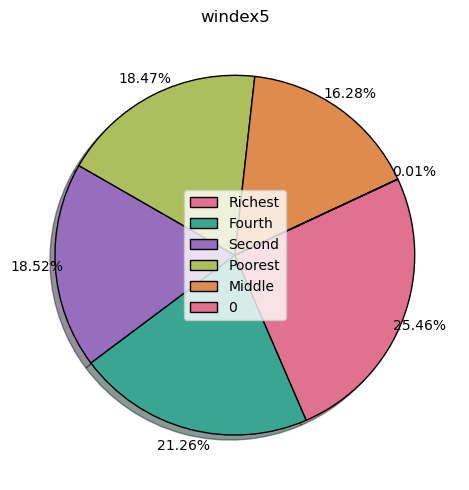

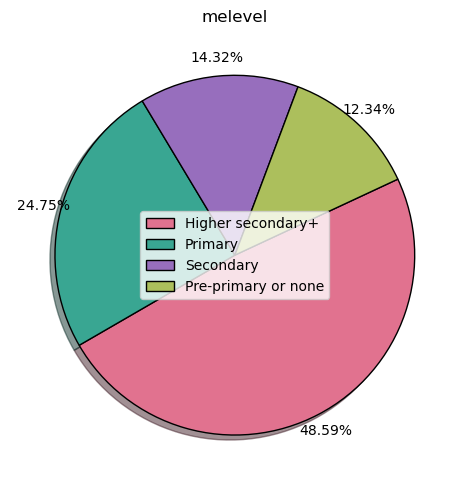

In [28]:
for col in categorical_features.columns:
    columns_failure_type = df1[col].unique().tolist()  # Types of failures

    plt.rcParams["figure.figsize"] = (5,5)
    colors = ['#E1728F', '#39A692', '#976EBD', '#ACBF5C', '#DF8B4E']

    plt.pie(df1[col].value_counts(), explode=None, autopct='%.2f%%',
            wedgeprops={'edgecolor': 'black'}, counterclock=False, shadow=True, startangle=25,
            pctdistance=1.1, radius=1, colors=colors)
    plt.legend(columns_failure_type, loc="center", fontsize=10)

    plt.title(col, fontsize=12)
    plt.tight_layout()
    plt.show()

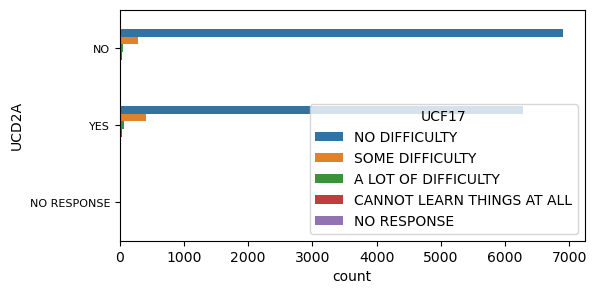

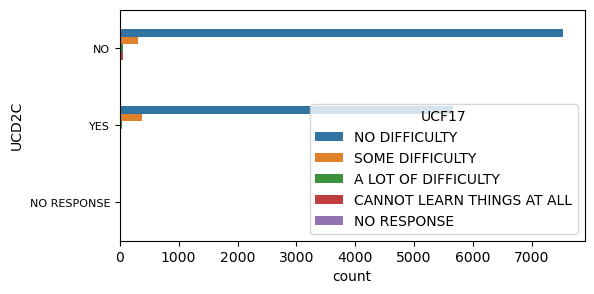

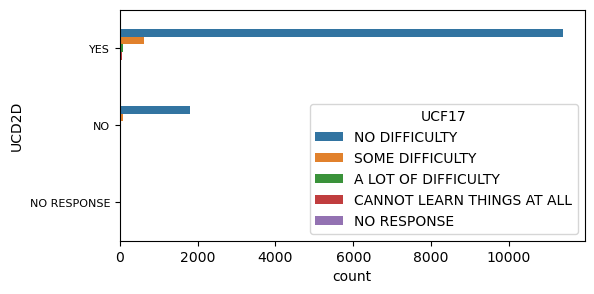

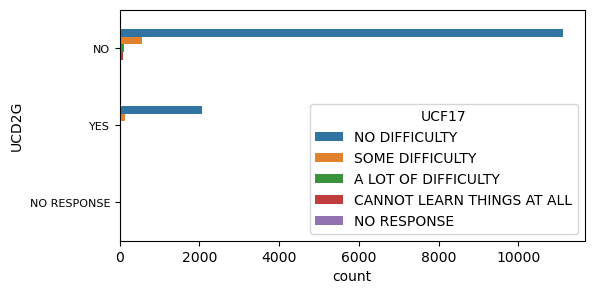

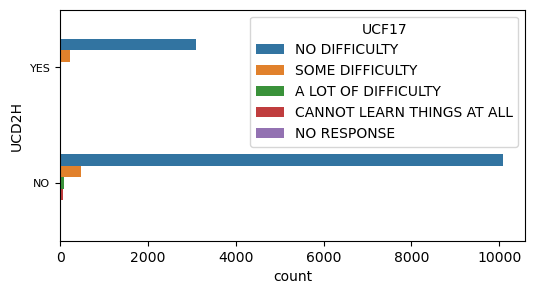

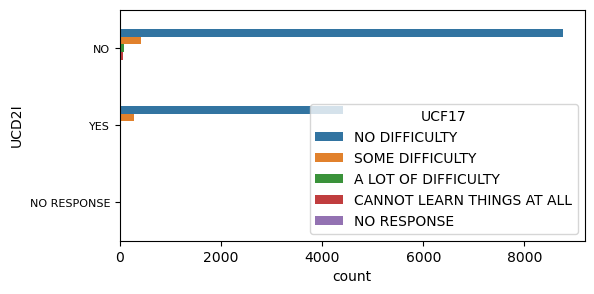

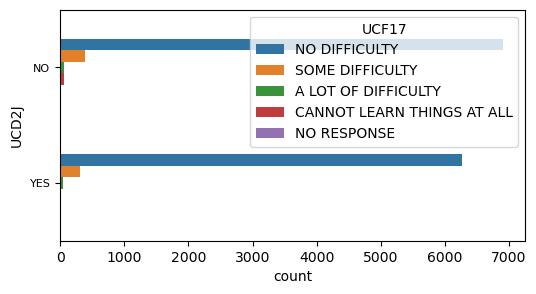

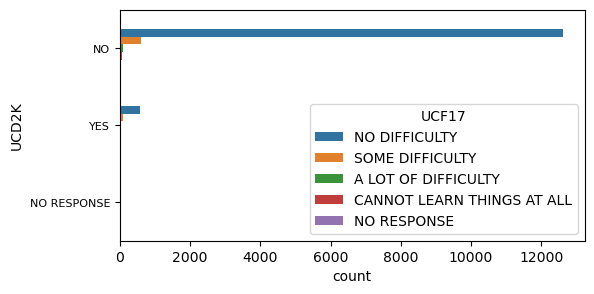

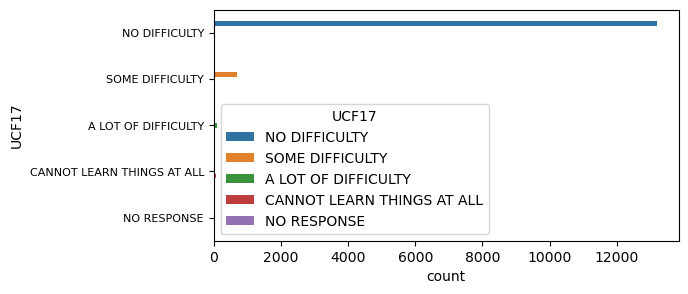

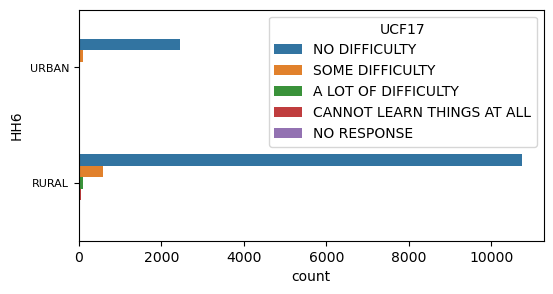

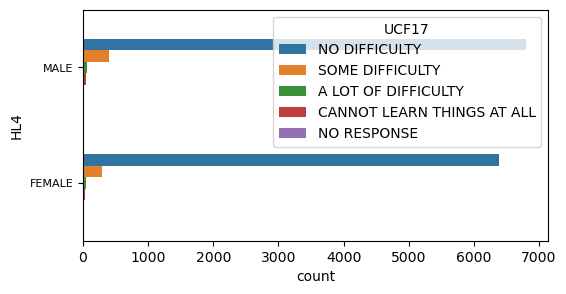

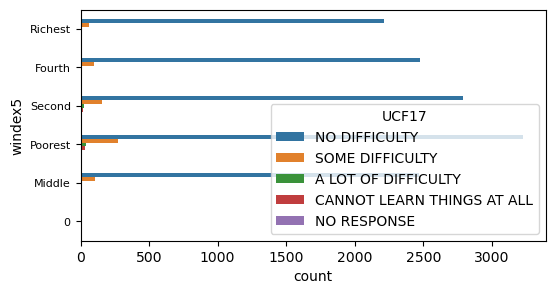

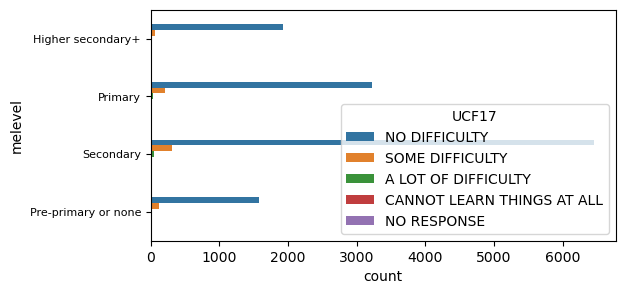

In [29]:
for col in categorical_features.columns:
    plt.figure(figsize=(6,3))
    
    sns.countplot(df1, y=col, hue='UCF17',width=.5)
    plt.xticks(rotation = 0, fontsize=10)
    plt.yticks(rotation = 0, fontsize=8)
    plt.xlabel('count',fontsize=10)
    plt.ylabel(col,fontsize=10)
    plt.show()

### Numerical Data

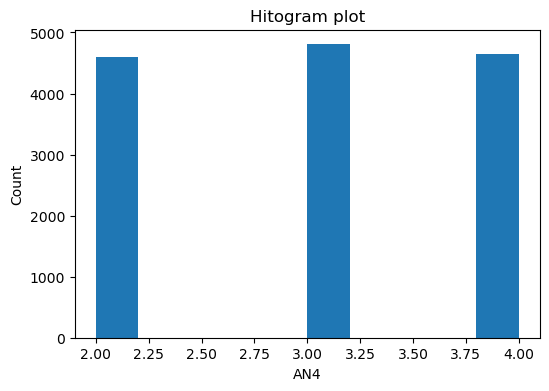

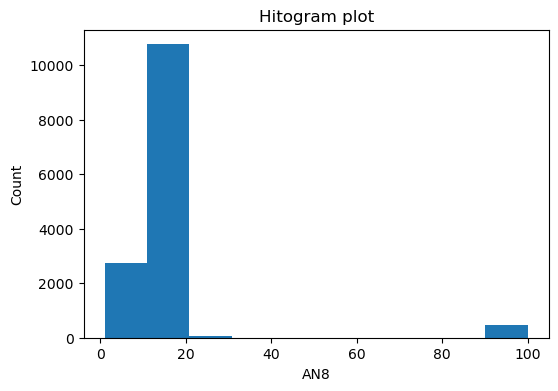

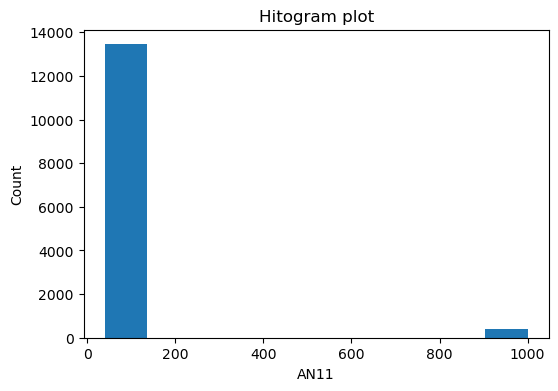

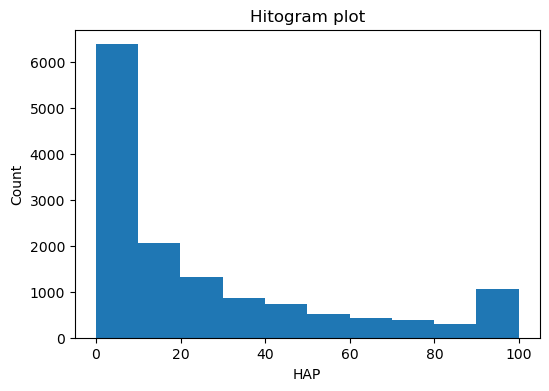

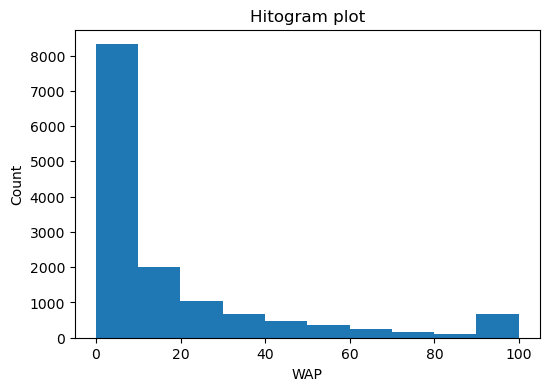

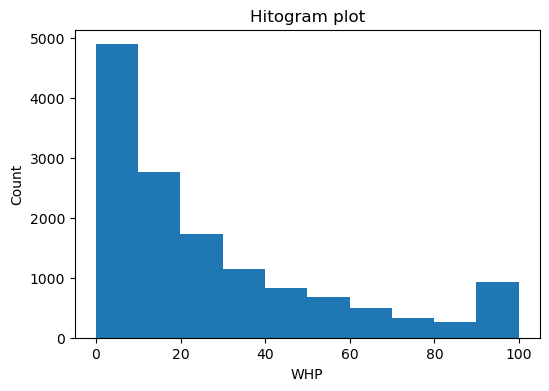

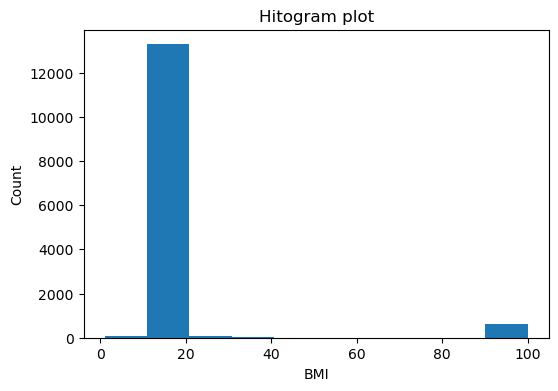

In [30]:
for col in numeric_features.columns:
    plt.figure(figsize = (6,4))
    fig=plt.hist(df1[col]) 
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title("Hitogram plot")
    plt.show(fig)

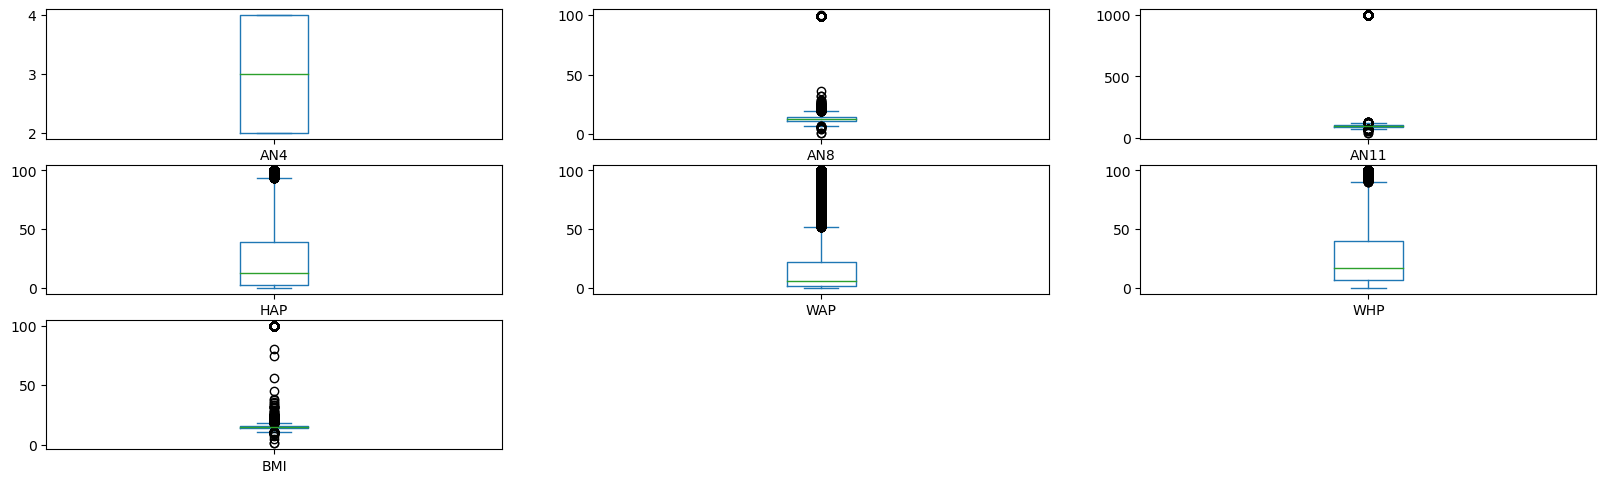

In [31]:
from matplotlib import pyplot

numeric_features.plot(kind='box', subplots=True, layout=(20,3), sharex=False, sharey=False,  figsize=(20, 40))
pyplot.show()

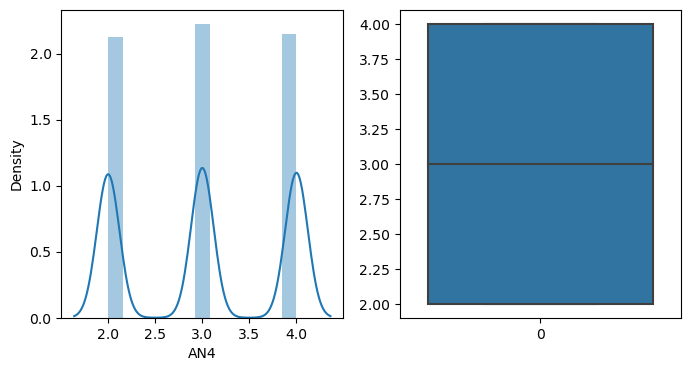

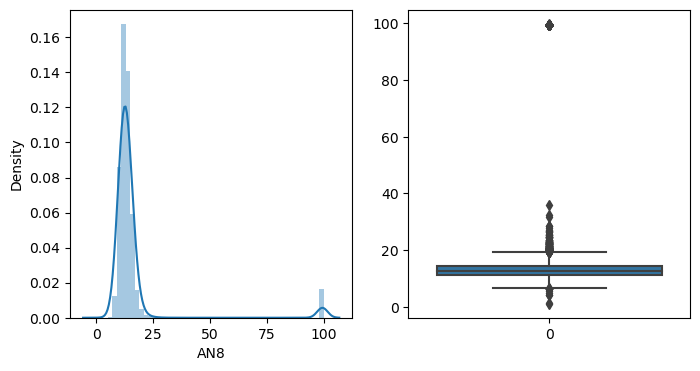

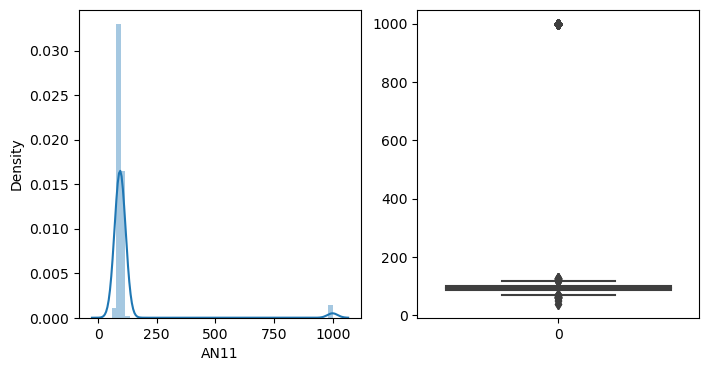

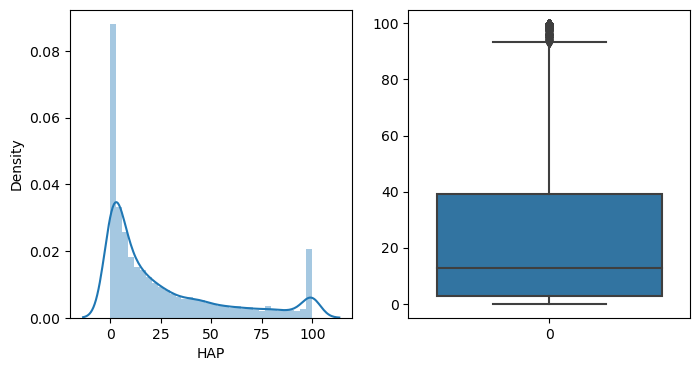

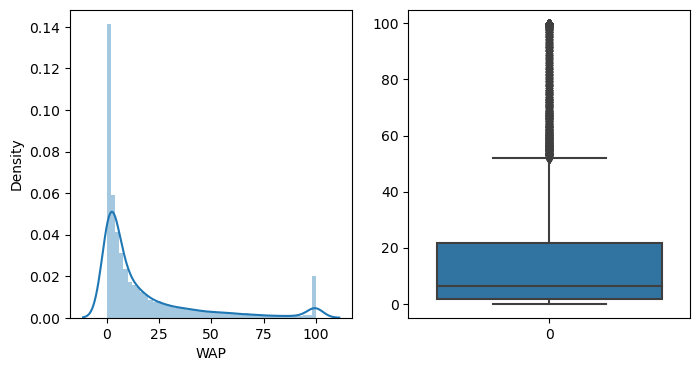

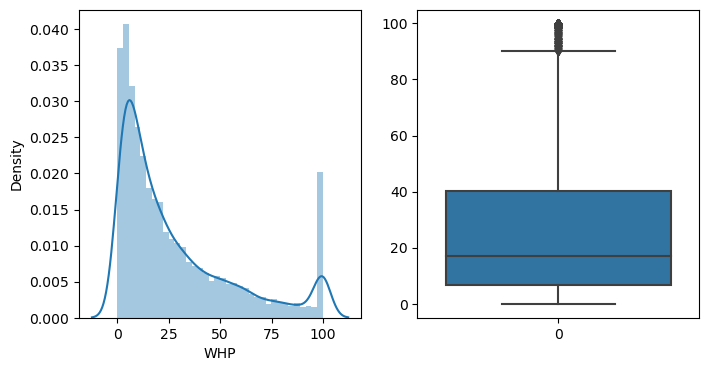

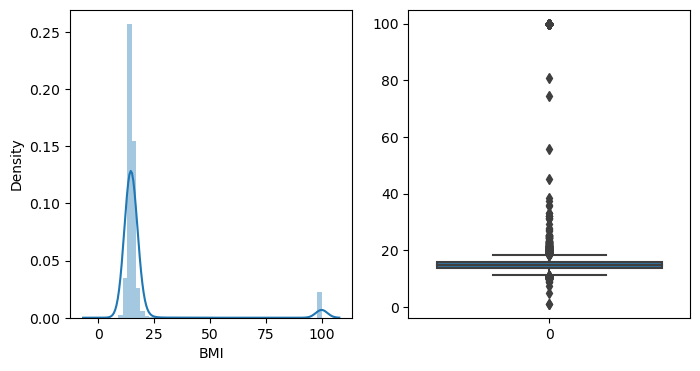

In [32]:
for column in numeric_features:
    plt.figure(figsize=(8,4))
    plt.subplot(1, 2, 1)
    sns.distplot(df1[column])
    plt.subplot(1, 2, 2)
    sns.boxplot(df1[column])

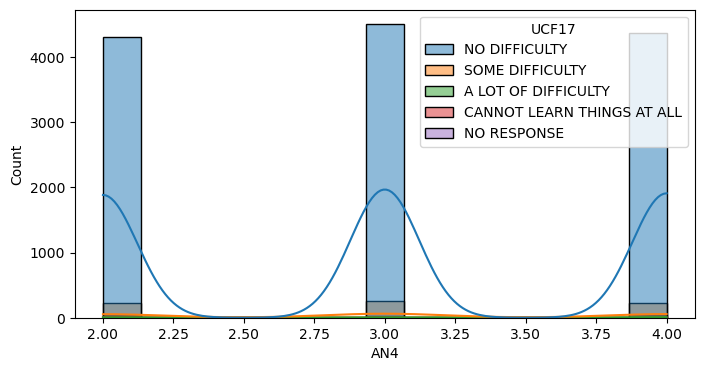

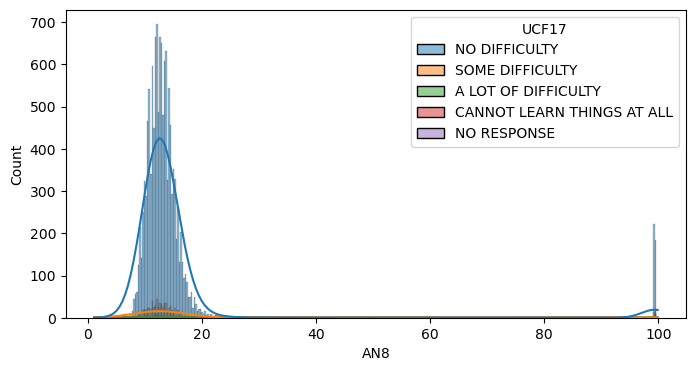

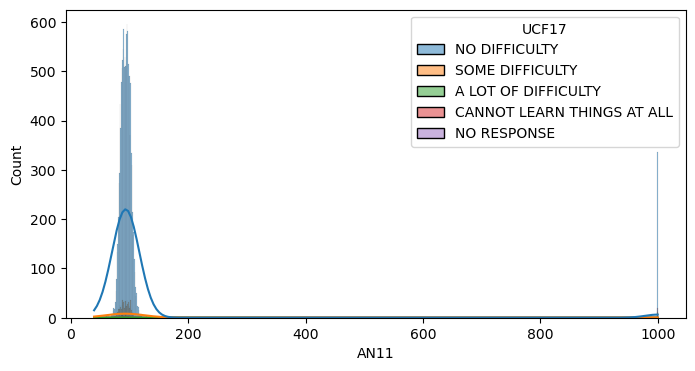

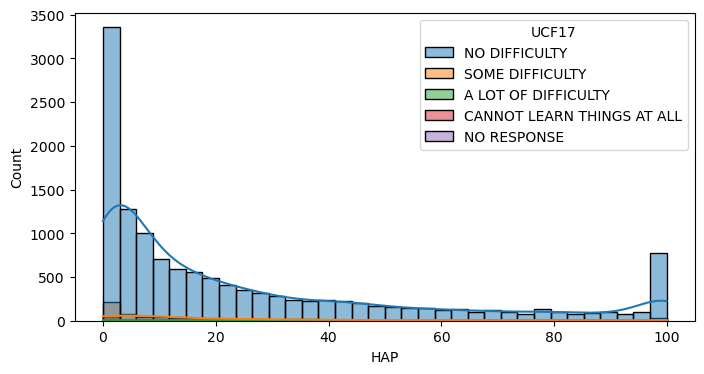

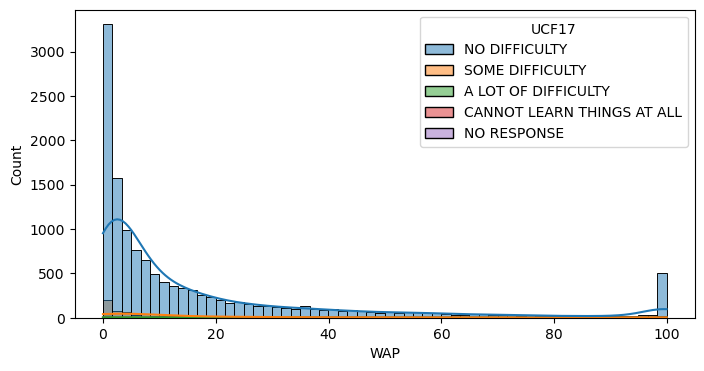

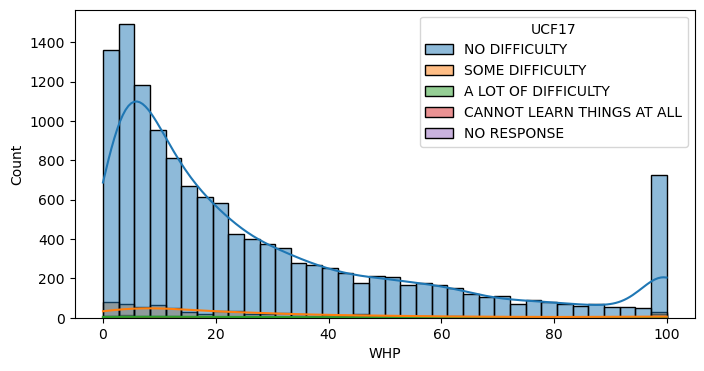

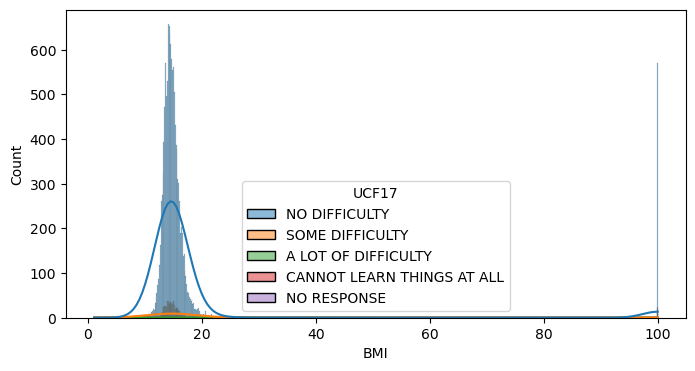

In [33]:
for column in numeric_features.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(x=column, data=df1, kde=True, hue='UCF17')
    plt.show()

In [34]:
import scipy.stats as stat
import pylab 

AN4


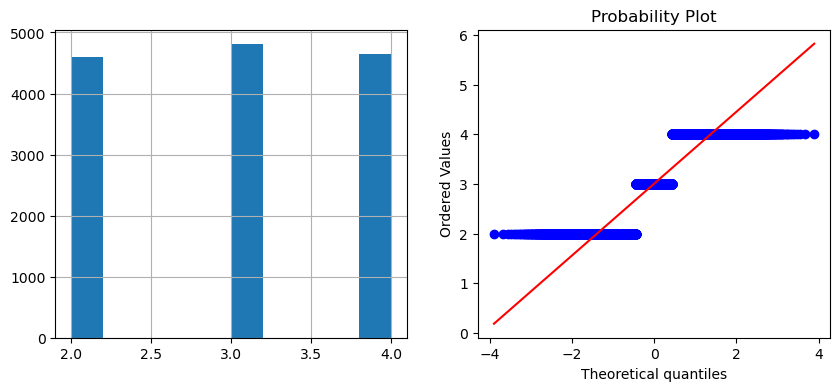

AN8


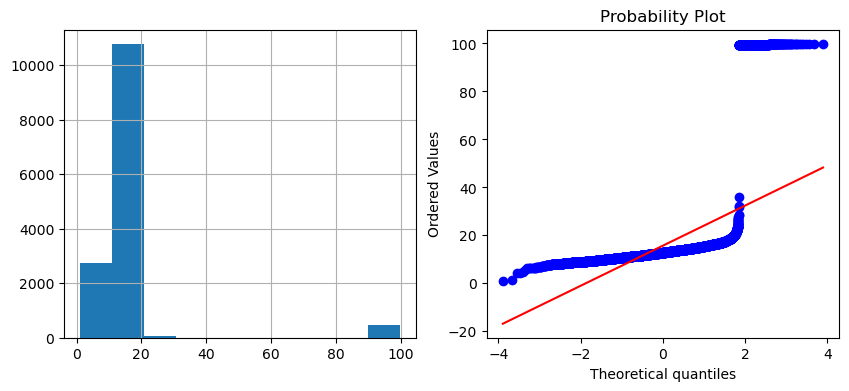

AN11


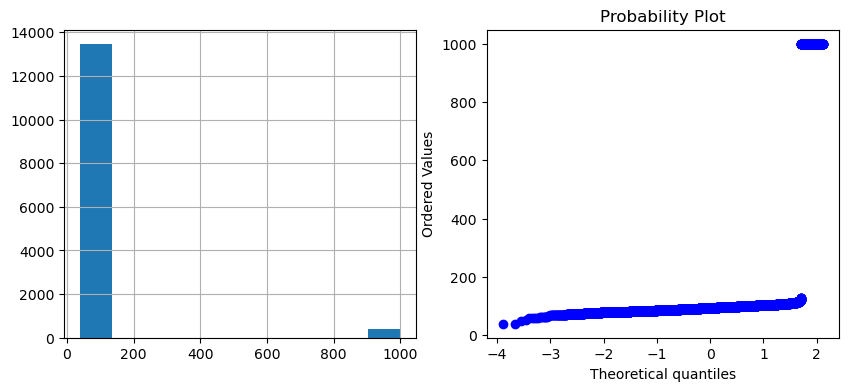

HAP


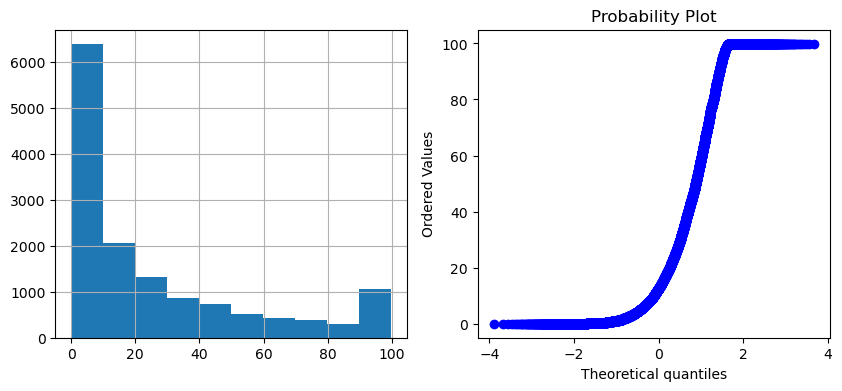

WAP


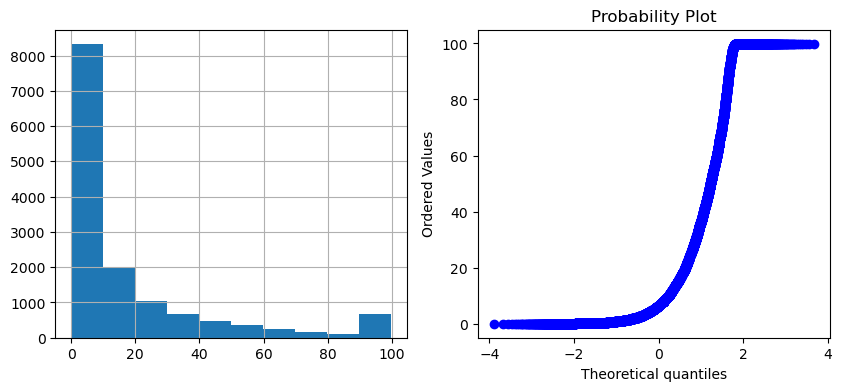

WHP


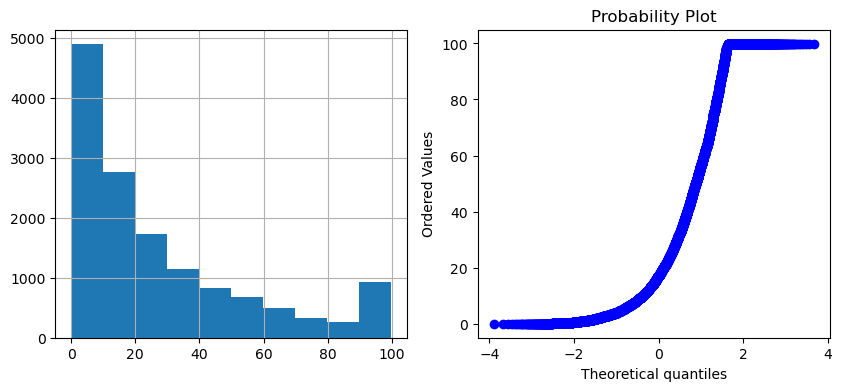

BMI


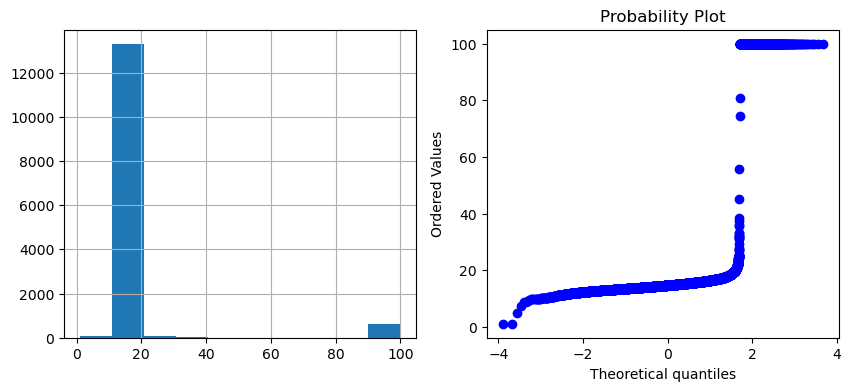

In [35]:
#### If you want to check whether feature is guassian or normal distributed
#### Q-Q plot
def plot_data(df,feature):
    print(feature)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    df[feature].hist()
    plt.subplot(1,2,2)
    stat.probplot(df[feature],dist='norm',plot=pylab)
    plt.show()
for column in numeric_features.columns:
    plot_data(df1,column)

Age_exponential


<Figure size 1000x400 with 0 Axes>

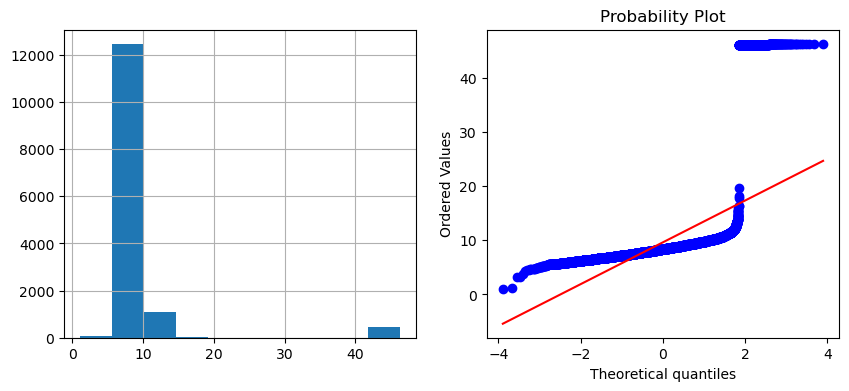

In [36]:
#### Exponential Transdormation
df1['Age_exponential']=df1['AN8']**(1/1.2)
plt.figure(figsize=(10,4))
plot_data(df1,'Age_exponential')

<Axes: >

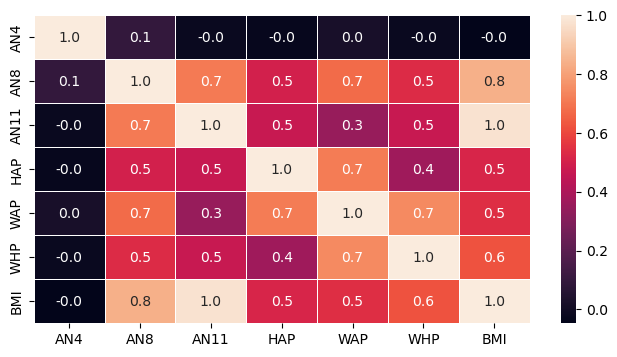

In [37]:
#correlation map
f,ax = plt.subplots(figsize=(8, 4))
sns.heatmap(numeric_features.corr(), annot=True, linewidths=.5, fmt= '.1f',ax=ax)

In [38]:
cormat = numeric_features.corr()
round(cormat,2)

,AN4,AN8,AN11,HAP,WAP,WHP,BMI
AN4,1.00,0.09,-0.02,-0.03,0.02,-0.02,-0.05
AN8,0.09,1.00,0.71,0.50,0.67,0.53,0.84
AN11,-0.02,0.71,1.00,0.47,0.35,0.46,0.97
HAP,-0.03,0.50,0.47,1.00,0.71,0.37,0.52
WAP,0.02,0.67,0.35,0.71,1.00,0.74,0.54
WHP,-0.02,0.53,0.46,0.37,0.74,1.00,0.62
BMI,-0.05,0.84,0.97,0.52,0.54,0.62,1.00


In [39]:
co_matrix = numeric_features.corr()

def correlation(df1, threshold):
    threshold=abs(threshold)
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = df1.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

corr_features = correlation(numeric_features, 0.9)
print('correlated features: ', len(set(corr_features)) )
corr_features


correlated features:  1


{'BMI'}